# 📚 Análise do Dataset de Performance de Estudantes de Ensino Médio

Aluna: Vitória Mendonça Justino
Disciplina: LIA1 - 2026.1

## 🎯 Objetivo do Estudo
Serão aplicadas as técnicas aprendidas para analisar o dataset: **Student Performance Dataset**!

### 🔍 Perguntas que vamos responder:
1. **📉 O número de faltas influenciou o desempenho acadêmico (GPA)?**
2. **📚 Estudantes que estudam mais horas por semana têm melhor desempenho?**
3. **👨‍👩‍👧 O nível de apoio parental está associado a melhores resultados acadêmicos?**
4. **🎓 Estudantes que recebem tutoria apresentam desempenho acadêmico superior?**
5. **⚽ A participação em atividades extracurriculares afeta o desempenho acadêmico?**

> **🎯 Meta:** Descobrir padrões e fatores que influenciam o desempenho acadêmico dos estudantes (GPA) por meio de análises exploratórias e visualizações de dados.

### 📊 Sobre o Dataset:
- **📅 Período:** Não especificado (dataset publicado em 2024)
- **👥 Estudantes:** 2.392 estudantes de ensino médio
- **📈 Desempenho analisado:** GPA (Grade Point Average) e indicadores acadêmicos
- **🔢 Variáveis:** Gênero, idade, tempo semanal de estudo, número de faltas, participação em atividades extracurriculares, nível de apoio parental, tutoria, entre outras características educacionais e comportamentais.

### 🔎 Sobre os dados:

#### Dados demográficos:
**Age:** Idade dos estudantes, em um intervalo de 15 a 18.

**Gender:** Gênero dos estudantes, em que 0 indica Homem e 1 indica Mulher.

**Ethnicity:** Dados de etina dos estudantes:
- **0:** Caucasian
- **1:** African American
- **2:** Asian
- **3:** Other

**ParentalEducation:** Nível de formação dos pais:
- **0:** Sem escolaridade formal
- **1:** Ensino médio completo
- **2:** Ensino médio incompleto
- **3:** Ensino superior completo
- **4:** Pós-graduação (especialização, mestrado ou doutorado)

#### Hábitos de estudo:
- **StudyTimeWeekly:** Tempo de estudo semanal em horas, em um intervalo de 0 a 20.
- **Absences:** Número de faltas ao longo do ano escolar, em um intervalo de 0 a 30.
- **Tutoring:** Indica o status de tutoria, onde 0 indica Não e 1 indica Sim.

#### GradeClass: Classificação dos estudantes com base na GPA:
- **0:** 'A' (GPA >= 3.5)
- **1:** 'B' (3.0 <= GPA < 3.5)
- **2:** 'C' (2.5 <= GPA < 3.0)
- **3:** 'D' (2.0 <= GPA < 2.5)
- **4:** 'F' (GPA < 2.0)

#### ParentalSupport: Nível de suporte parenta;:
- **0:** Nenhum
- **1:** Baixo
- **2:** Moderado
- **3:** Alto
- **4:** Muito alto

#### Atividades extracurriculatres: 0 indica Não e 1 indica Sim
- **Extracurricular:** Participação em atividades extracurriculares.
- **Sports:** Participação em atividades esportivas.
- **Music:** Participação em atividades com música.
- **Volunteering:** Participação em atividades voluntárias.

## 📁 a) Carregando e Preparando os Dados

### 🧹 Etapas de Limpeza:
1. **📥 Carregar** o dataset
2. **🔍 Explorar** a estrutura dos dados
3. **🧹 Limpar** valores ausentes
4. **🗂️ Preparar** para análise


In [14]:
# Carregando o Students Performance Dataset
print("📚 Carregando o Students Performance Dataset...")

# Importando as bibliotecas necessárias
import os
import glob
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações para gráficos
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Baixa o dataset para uma pasta local
dataset_path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
print(f"📂 Dataset baixado em: {dataset_path}")

# Procura automaticamente o primeiro CSV da pasta
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta do dataset.")

# Lê o arquivo CSV
csv_path = csv_files[0]
students = pd.read_csv(csv_path)

print("\n📊 Informações básicas do dataset:")
print(f"📏 Dimensões: {students.shape}")
print(f"📋 Colunas: {list(students.columns)}")

print("\n🔍 Primeiras 5 linhas:")
students.head()

📚 Carregando o Students Performance Dataset...
📂 Dataset baixado em: C:\Users\vitor\.cache\kagglehub\datasets\rabieelkharoua\students-performance-dataset\versions\2

📊 Informações básicas do dataset:
📏 Dimensões: (2392, 15)
📋 Colunas: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

🔍 Primeiras 5 linhas:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [15]:
print("\n🧹 Verificando dados ausentes:")
dados_ausentes = students.isnull().sum()
print(dados_ausentes[dados_ausentes > 0])

print("\n🔧 Realizando limpeza dos dados...")

# 1. Remover linhas duplicadas, se houver
students = students.drop_duplicates()

# 2. Preencher valores ausentes numéricos com a média
colunas_numericas = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
for col in colunas_numericas:
    if col in students.columns and students[col].isnull().sum() > 0:
        students[col] = students[col].fillna(students[col].mean())

# 3. Preencher valores ausentes categóricos com o valor mais comum (moda)
colunas_categoricas = ['Gender', 'Ethnicity', 'ParentalEducation',
                       'Tutoring', 'ParentalSupport', 'Extracurricular',
                       'Sports', 'Music', 'Volunteering', 'GradeClass']
for col in colunas_categoricas:
    if col in students.columns and students[col].isnull().sum() > 0:
        students[col] = students[col].fillna(students[col].mode()[0])

# 4. Remover StudentID (não será utilizada na análise
if 'StudentID' in students.columns:
    students = students.drop('StudentID', axis=1)

print("✅ Dataset Students Performance pronto para análise!")
print(f"📏 Dimensões finais: {students.shape}")
print(f"🧹 Dados ausentes restantes: {students.isnull().sum().sum()}")

# Estatísticas gerais de desempenho
media_gpa = students['GPA'].mean()
mediana_gpa = students['GPA'].median()
gpa_max = students['GPA'].max()
gpa_min = students['GPA'].min()

print(f"\n📊 Média geral de GPA: {media_gpa:.2f}")
print(f"📍 Mediana do GPA: {mediana_gpa:.2f}")
print(f"📈 Maior GPA: {gpa_max:.2f}")
print(f"📉 Menor GPA: {gpa_min:.2f}")
print(f"👥 Total de estudantes: {len(students)}")

# Distribuição da classificação final
if 'GradeClass' in students.columns:
    print("\n🏆 Distribuição de GradeClass:")
    print(students['GradeClass'].value_counts().sort_index())


🧹 Verificando dados ausentes:
Series([], dtype: int64)

🔧 Realizando limpeza dos dados...
✅ Dataset Students Performance pronto para análise!
📏 Dimensões finais: (2392, 14)
🧹 Dados ausentes restantes: 0

📊 Média geral de GPA: 1.91
📍 Mediana do GPA: 1.89
📈 Maior GPA: 4.00
📉 Menor GPA: 0.00
👥 Total de estudantes: 2392

🏆 Distribuição de GradeClass:
GradeClass
0.0     107
1.0     269
2.0     391
3.0     414
4.0    1211
Name: count, dtype: int64


## 📊 b) Análise Exploratória com Gráficos

Vamos usar visualizações para responder nossas perguntas de pesquisa!

### 📉 Pergunta 1: O número de faltas influenciou o desempenho acadêmico (GPA)?
> **Hipótese:** Estudantes com maior número de faltas tendem a apresentar valores menores de GPA.

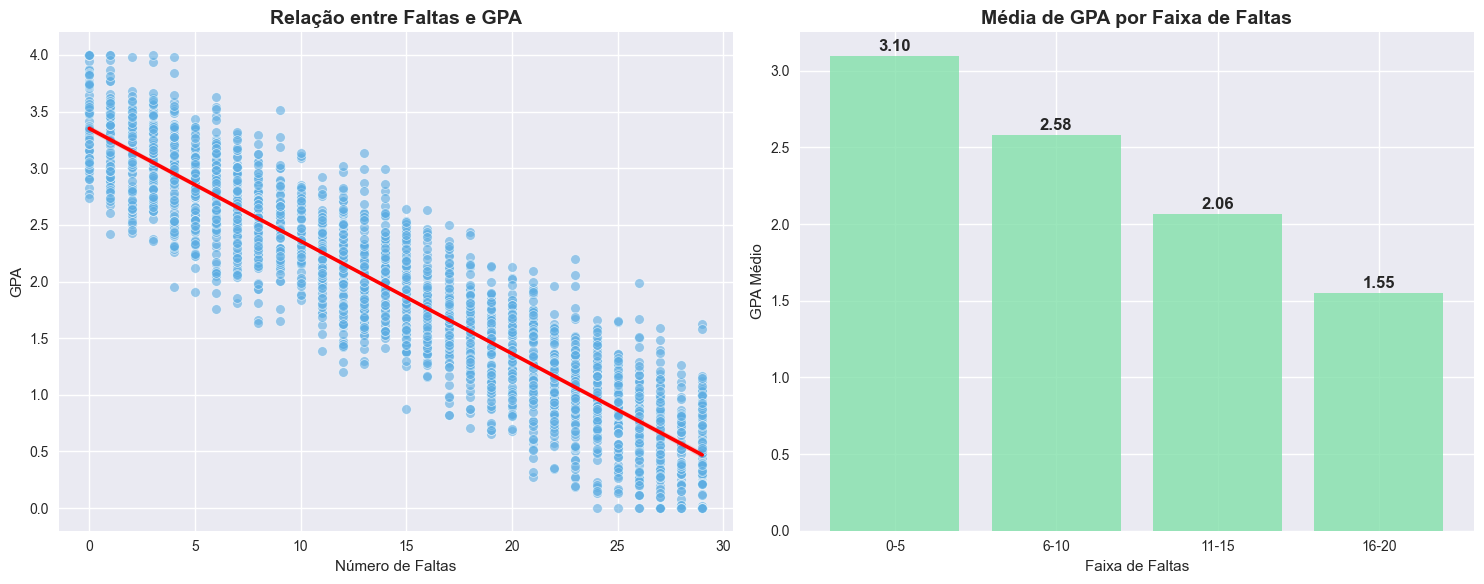

📊 Análise Estatística - Faltas vs GPA
🔗 Correlação entre faltas e GPA: -0.92

📋 Média de GPA por faixa de faltas:
Faixa_Faltas
0-5      3.095303
6-10     2.582602
11-15    2.064786
16-20    1.552054
Name: GPA, dtype: float64

🔍 Insights:
✓ Existe uma relação negativa entre faltas e desempenho acadêmico
✓ Alunos com mais faltas tendem a apresentar menor GPA

📌 Conclusão:
A análise gráfica e a correlação indicam que a frequência escolar pode influenciar o desempenho acadêmico dos estudantes.


In [19]:
# Pergunta 1: O número de faltas influenciou o desempenho acadêmico (GPA)?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Relação entre faltas e GPA (scatter)
sns.scatterplot(
    x='Absences',
    y='GPA',
    data=students,
    alpha=0.6,
    color='#5DADE2',
    ax=ax1
)

sns.regplot(
    x='Absences',
    y='GPA',
    data=students,
    scatter=False,
    color='red',
    ax=ax1
)

ax1.set_title('Relação entre Faltas e GPA', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Faltas')
ax1.set_ylabel('GPA')


# Criando faixas de faltas para análise
students['Faixa_Faltas'] = pd.cut(
    students['Absences'],
    bins=[-1, 5, 10, 15, 20],
    labels=['0-5', '6-10', '11-15', '16-20']
)

# Gráfico 2: Média do GPA por faixa de faltas
media_gpa_faltas = students.groupby('Faixa_Faltas')['GPA'].mean()

ax2.bar(
    media_gpa_faltas.index,
    media_gpa_faltas.values,
    color='#82E0AA',
    alpha=0.8
)

ax2.set_title('Média de GPA por Faixa de Faltas', fontsize=14, fontweight='bold')
ax2.set_xlabel('Faixa de Faltas')
ax2.set_ylabel('GPA Médio')

# Adicionando valores nas barras
for i, v in enumerate(media_gpa_faltas.values):
    ax2.text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# Análise estatística
print("📊 Análise Estatística - Faltas vs GPA")
print("=" * 50)

correlacao = students['Absences'].corr(students['GPA'])

print(f"🔗 Correlação entre faltas e GPA: {correlacao:.2f}")

print("\n📋 Média de GPA por faixa de faltas:")
print(media_gpa_faltas)

print("\n🔍 Insights:")

if correlacao < 0:
    print("✓ Existe uma relação negativa entre faltas e desempenho acadêmico")
    print("✓ Alunos com mais faltas tendem a apresentar menor GPA")
else:
    print("✓ Não foi observada relação negativa clara entre faltas e GPA")

print("\n📌 Conclusão:")
print("A análise gráfica e a correlação indicam que a frequência escolar pode influenciar o desempenho acadêmico dos estudantes.")

### 📚 Pergunta 2: Estudantes que estudam mais horas por semana têm melhor desempenho?
> **Hipótese:** Estudantes que dedicam mais horas semanais ao estudo apresentam melhor desempenho acadêmico, refletido em valores mais elevados de GPA.

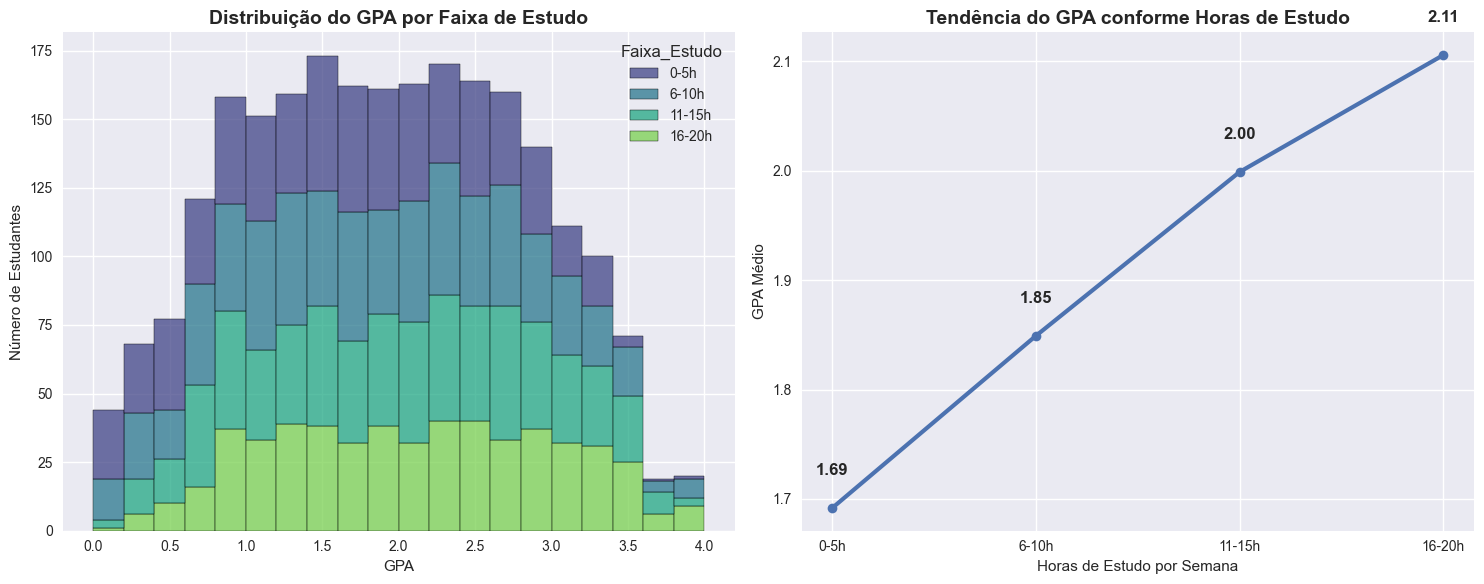

📊 Análise Estatística - Tempo de Estudo vs GPA
Correlação entre horas de estudo e GPA: 0.18

📋 Média de GPA por faixa de estudo:
Faixa_Estudo
0-5h      1.691647
6-10h     1.849145
11-15h    1.999016
16-20h    2.105937
Name: GPA, dtype: float64

🔍 Insights:
✓ Estudantes que estudam entre 16 e 20 horas por semana apresentam o maior desempenho médio (≈ 2,11), enquanto aqueles que estudam até 5 horas apresentam o menor (≈ 1,69).
✓ A média do GPA cresce de forma relativamente constante entre as faixas de estudo.
✓ Embora exista uma tendência de melhora do GPA com mais horas de estudo, há grande variabilidade dentro de cada grupo. Isso indica que outros fatores também influenciam o desempenho acadêmico.

📌 Conclusão:
Existe uma associação positiva entre o tempo semanal de estudo e o desempenho acadêmico, com estudantes que dedicam mais horas ao estudo apresentando, em média, valores mais altos de GPA.


In [23]:
# Pergunta 2: Estudantes que estudam mais horas por semana têm melhor desempenho?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

# Criando faixas de estudo
students['Faixa_Estudo'] = pd.cut(
    students['StudyTimeWeekly'],
    bins=[0,5,10,15,20],
    labels=['0-5h','6-10h','11-15h','16-20h']
)

# Gráfico 1: Histograma do GPA por faixa de estudo
sns.histplot(
    data=students,
    x='GPA',
    hue='Faixa_Estudo',
    bins=20,
    palette='viridis',
    multiple='stack',
    ax=ax1
)

ax1.set_title('Distribuição do GPA por Faixa de Estudo', fontsize=14, fontweight='bold')
ax1.set_xlabel('GPA')
ax1.set_ylabel('Número de Estudantes')


# Gráfico 2: Tendência média do GPA conforme estudo
media_estudo = students.groupby('Faixa_Estudo')['GPA'].mean()

ax2.plot(
    media_estudo.index,
    media_estudo.values,
    marker='o',
    linewidth=3
)

ax2.set_title('Tendência do GPA conforme Horas de Estudo', fontsize=14, fontweight='bold')
ax2.set_xlabel('Horas de Estudo por Semana')
ax2.set_ylabel('GPA Médio')

# valores nos pontos
for i, v in enumerate(media_estudo.values):
    ax2.text(i, v+0.03, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Análise estatística
print("📊 Análise Estatística - Tempo de Estudo vs GPA")
print("="*50)

correlacao = students['StudyTimeWeekly'].corr(students['GPA'])
print(f"Correlação entre horas de estudo e GPA: {correlacao:.2f}")

print("\n📋 Média de GPA por faixa de estudo:")
print(media_estudo)

print("\n🔍 Insights:")
print("✓ Estudantes que estudam entre 16 e 20 horas por semana apresentam o maior desempenho médio (≈ 2,11), enquanto aqueles que estudam até 5 horas apresentam o menor (≈ 1,69).")
print("✓ A média do GPA cresce de forma relativamente constante entre as faixas de estudo.")
print("✓ Embora exista uma tendência de melhora do GPA com mais horas de estudo, há grande variabilidade dentro de cada grupo. Isso indica que outros fatores também influenciam o desempenho acadêmico.")

print("\n📌 Conclusão:")
print("Existe uma associação positiva entre o tempo semanal de estudo e o desempenho acadêmico, com estudantes que dedicam mais horas ao estudo apresentando, em média, valores mais altos de GPA.")

### 👨‍👩‍👧 Pergunta 3: O nível de apoio parental está associado a melhores resultados acadêmicos?
> **Hipótese:** Estudantes que apresentam maior nível de apoio parental tendem a obter melhor desempenho acadêmico, refletido em valores mais elevados de GPA.

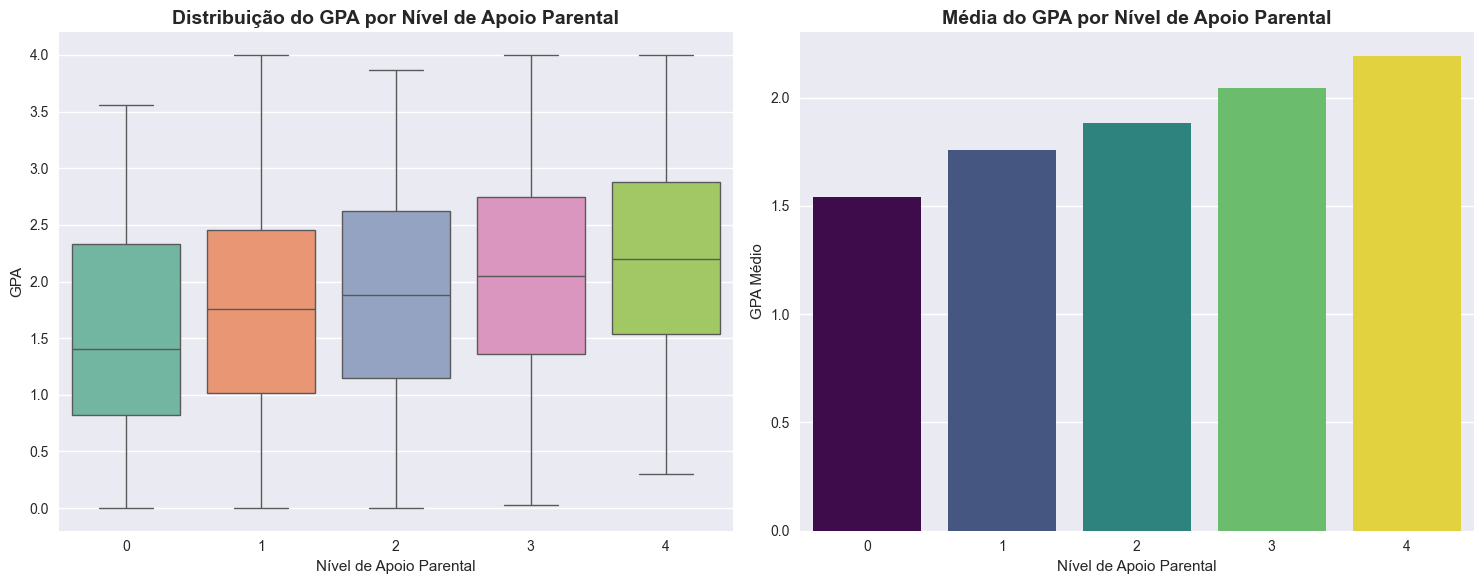

📊 Análise Estatística - Apoio Parental vs GPA

📋 Média de GPA por nível de apoio parental:
ParentalSupport
0    1.540128
1    1.755700
2    1.884246
3    2.042409
4    2.191545
Name: GPA, dtype: float64

🔍 Insights:
✓ Estudantes com nível de apoio 4 apresentam o maior GPA médio (≈ 2,19), enquanto aqueles com nível 0 apresentam o menor (≈ 1,54).
✓ A média de GPA aumenta gradualmente entre os níveis de apoio parental
✓ O boxplot mostra que existe variabilidade significativa dentro de cada grupo. Isso indica que outros fatores também influenciam o desempenho acadêmico.

📌 Conclusão:
Há uma associação positiva entre o nível de apoio parental e o desempenho acadêmico dos estudantes. Estudantes que recebem maior suporte familiar apresentam, em média, valores mais elevados de GPA.
Embora essa relação não determine completamente o desempenho acadêmico, os gráficos sugerem que o apoio parental pode desempenhar um papel relevante no sucesso educacional, possivelmente ao favorecer maior motivação

In [31]:
# Pergunta 3: O nível de apoio parental está associado a melhores resultados acadêmicos?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

# Gráfico 1: Distribuição do GPA por apoio parental\
sns.boxplot(
    x='ParentalSupport',
    y='GPA',
    hue='ParentalSupport',
    data=students,
    palette='Set2',
    legend=False,
    ax=ax1
)

ax1.set_title('Distribuição do GPA por Nível de Apoio Parental', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nível de Apoio Parental')
ax1.set_ylabel('GPA')


# Gráfico 2: Média do GPA por apoio parental
sns.barplot(
    x='ParentalSupport',
    y='GPA',
    hue='ParentalSupport',
    data=students,
    palette='viridis',
    errorbar=None,
    legend=False,
    ax=ax2
)

ax2.set_title('Média do GPA por Nível de Apoio Parental', fontsize=14, fontweight='bold')
ax2.set_xlabel('Nível de Apoio Parental')
ax2.set_ylabel('GPA Médio')


plt.tight_layout()
plt.show()


# Análise estatística
print("📊 Análise Estatística - Apoio Parental vs GPA")
print("="*50)

media_support = students.groupby('ParentalSupport')['GPA'].mean()

print("\n📋 Média de GPA por nível de apoio parental:")
print(media_support)

print("\n🔍 Insights:")
print("✓ Estudantes com nível de apoio 4 apresentam o maior GPA médio (≈ 2,19), enquanto aqueles com nível 0 apresentam o menor (≈ 1,54).")
print("✓ A média de GPA aumenta gradualmente entre os níveis de apoio parental")
print("✓ O boxplot mostra que existe variabilidade significativa dentro de cada grupo. Isso indica que outros fatores também influenciam o desempenho acadêmico.")

print("\n📌 Conclusão:")
print("Há uma associação positiva entre o nível de apoio parental e o desempenho acadêmico dos estudantes. Estudantes que recebem maior suporte familiar apresentam, em média, valores mais elevados de GPA.")
print("Embora essa relação não determine completamente o desempenho acadêmico, os gráficos sugerem que o apoio parental pode desempenhar um papel relevante no sucesso educacional, possivelmente ao favorecer maior motivação, acompanhamento das atividades escolares e criação de um ambiente propício ao estudo.")

### 🎓 Pergunta 4: Estudantes que recebem tutoria apresentam desempenho acadêmico superior?
> **Hipótese:** Estudantes que recebem tutoria acadêmica apresentam, em média, melhor desempenho acadêmico, refletido em valores mais elevados de GPA, quando comparados àqueles que não recebem tutoria.

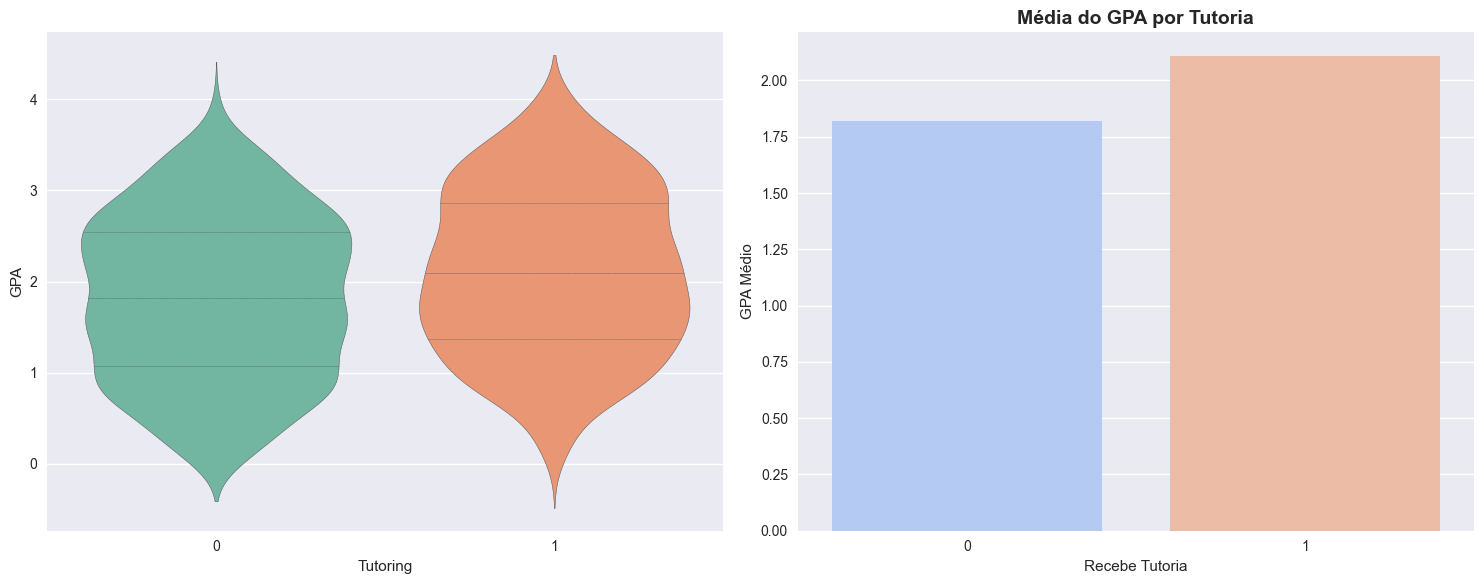

📊 Análise Estatística - Tutoria vs GPA

📋 Média de GPA por grupo:
Tutoring
0    1.818968
1    2.108325
Name: GPA, dtype: float64

🔍 Insights iniciais:
✓ GPA médio sem tutoria: 1.82
✓ GPA médio com tutoria: 2.11
✓ Diferença: 0.29
✓ O violin plot indica que estudantes sem tutoria também apresentam concentração relevante em valores mais altos de GPA.
✓ O violin plot indica que estudantes com tutoria apresentam concentração relevante em valores mais altos de GPA do que os que não receberam.

📌 Conclusão:
A análise sugere que estudantes que recebem tutoria apresentam GPA médio mais alto, indicando uma possível associação positiva entre tutoria e desempenho acadêmico.
Embora a tutoria esteja associada a um aumento no desempenho médio, seu impacto não parece ser determinante isoladamente, sendo provável que outros fatores também influenciem significativamente o desempenho acadêmico dos estudantes.


In [39]:
# Pergunta 4: Estudantes que recebem tutoria apresentam desempenho acadêmico superior?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

# Gráfico 1: Distribuição real dos dados
# sns.swarmplot(
#     x='Tutoring',
#     y='GPA',
#     hue='Tutoring',
#     data=students,
#     palette='Set1',
#     legend=False,
#     ax=ax1
# )

sns.violinplot(
    x='Tutoring',
    y='GPA',
    data=students,
    hue='Tutoring',
    palette='Set2',
    legend=False,
    inner='quartile',
    ax=ax1
)

ax.set_title('Distribuição do GPA por Tutoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Recebe Tutoria')
ax.set_ylabel('GPA')

# Gráfico 2: Média do GPA
sns.barplot(
    x='Tutoring',
    y='GPA',
    hue='Tutoring',
    data=students,
    palette='coolwarm',
    errorbar=None,
    legend=False,
    ax=ax2
)

ax2.set_title('Média do GPA por Tutoria', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recebe Tutoria')
ax2.set_ylabel('GPA Médio')

plt.tight_layout()
plt.show()

# Análise estatística
print("📊 Análise Estatística - Tutoria vs GPA")
print("="*50)

media_tutoria = students.groupby('Tutoring')['GPA'].mean()
print("\n📋 Média de GPA por grupo:")
print(media_tutoria)

print("\n🔍 Insights iniciais:")
print(f"✓ GPA médio sem tutoria: {media_tutoria[0]:.2f}")
print(f"✓ GPA médio com tutoria: {media_tutoria[1]:.2f}")
print(f"✓ Diferença: {(media_tutoria[1] - media_tutoria[0]):.2f}")
print("✓ O violin plot indica que estudantes sem tutoria também apresentam concentração relevante em valores mais altos de GPA.")
print("✓ O violin plot indica que estudantes com tutoria apresentam concentração relevante em valores mais altos de GPA do que os que não receberam.")

print("\n📌 Conclusão:")
print("A análise sugere que estudantes que recebem tutoria apresentam GPA médio mais alto, indicando uma possível associação positiva entre tutoria e desempenho acadêmico.")
print("Embora a tutoria esteja associada a um aumento no desempenho médio, seu impacto não parece ser determinante isoladamente, sendo provável que outros fatores também influenciem significativamente o desempenho acadêmico dos estudantes.")

### ⚽ Pergunta 5: A participação em atividades extracurriculares afeta o desempenho acadêmico?
> **Hipótese:** Estudantes que participam de atividades extracurriculares apresentam desempenho acadêmico diferente daqueles que não participam, refletido em valores distintos de GPA.

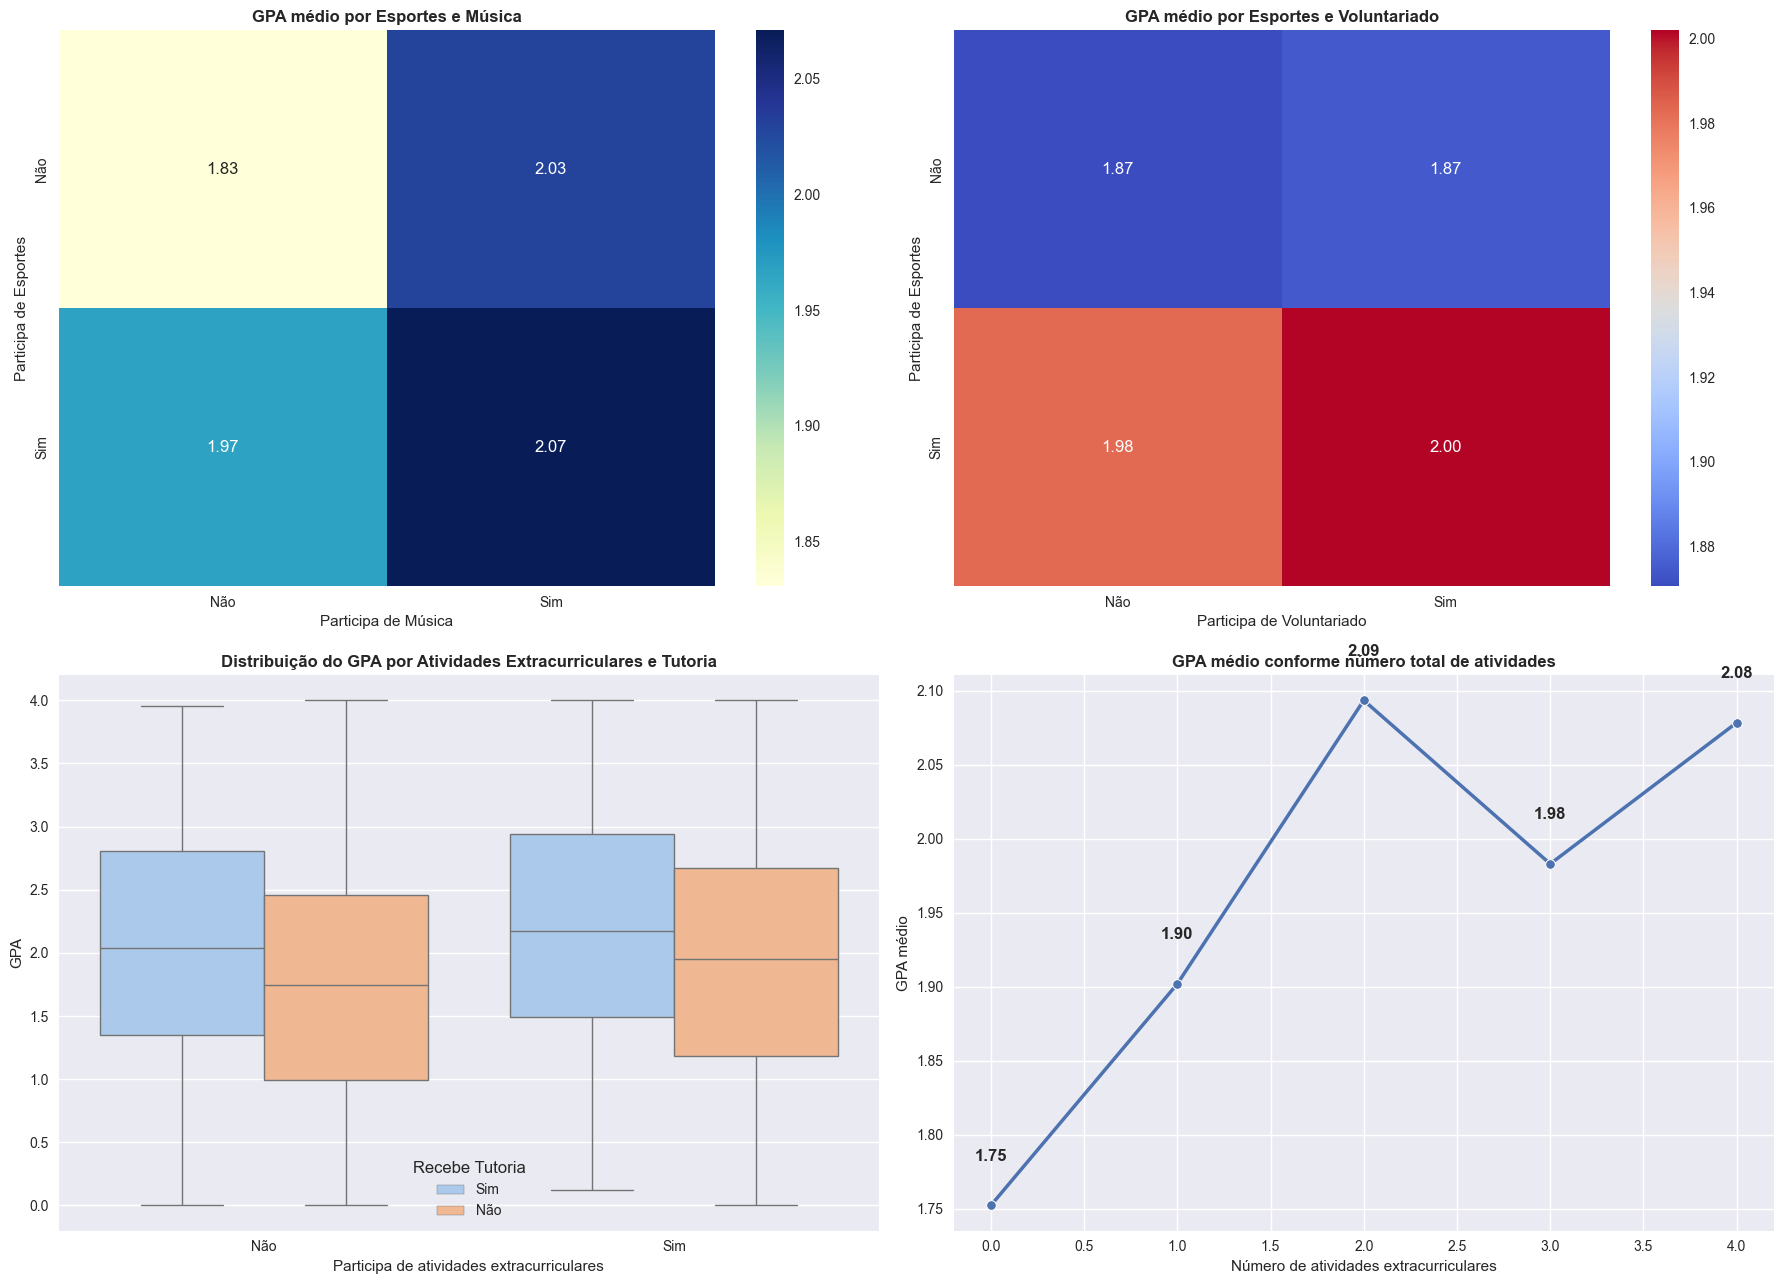


📋 Insights da Análise Combinada:
✅ Existe um possível efeito combinado positivo, sugerindo que estudantes envolvidos em múltiplas atividades culturais e físicas podem apresentar melhor desempenho acadêmico.
✅ A combinação de apoio acadêmico (tutoria) e participação extracurricular pode contribuir para melhores resultados acadêmicos.
✅ Estudantes sem atividades extracurriculares apresentam o menor GPA médio.
✅ O GPA médio aumenta progressivamente até cerca de duas atividades.
✅ Após duas atividades ocorre uma leve redução, sugerindo possível sobrecarga.
✅ Mesmo com essa redução, alunos com múltiplas atividades ainda apresentam desempenho superior aos que não participam de nenhuma.


In [48]:
# Preparação dos rótulos
students['Tutoring_label'] = students['Tutoring'].map({0: 'Não', 1: 'Sim'})
students['Extracurricular_label'] = students['Extracurricular'].map({0: 'Não', 1: 'Sim'})
students['Sports_label'] = students['Sports'].map({0: 'Não', 1: 'Sim'})
students['Music_label'] = students['Music'].map({0: 'Não', 1: 'Sim'})
students['Volunteering_label'] = students['Volunteering'].map({0: 'Não', 1: 'Sim'})

# Número total de atividades
students['Total_Atividades'] = (
    students['Extracurricular'] +
    students['Sports'] +
    students['Music'] +
    students['Volunteering']
)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 13))


# Gráfico 1: GPA médio por Esporte e Música
pivot1 = students.pivot_table(
    values='GPA',
    index='Sports_label',
    columns='Music_label',
    aggfunc='mean'
)

sns.heatmap(
    pivot1,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=ax1
)

ax1.set_title("GPA médio por Esportes e Música", fontweight='bold')
ax1.set_xlabel("Participa de Música")
ax1.set_ylabel("Participa de Esportes")


# Gráfico 2: GPA médio por Esportes e Voluntariado
pivot2 = students.pivot_table(
    values='GPA',
    index='Sports_label',
    columns='Volunteering_label',
    aggfunc='mean'
)

sns.heatmap(
    pivot2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax2
)

ax2.set_title("GPA médio por Esportes e Voluntariado", fontweight='bold')
ax2.set_xlabel("Participa de Voluntariado")
ax2.set_ylabel("Participa de Esportes")


# Gráfico 3: Distribuição GPA por Atividade Extracurricular + Tutoria
sns.boxplot(
    x='Extracurricular_label',
    y='GPA',
    hue='Tutoring_label',
    data=students,
    palette='pastel',
    ax=ax3
)

ax3.set_title("Distribuição do GPA por Atividades Extracurriculares e Tutoria", fontweight='bold')
ax3.set_xlabel("Participa de atividades extracurriculares")
ax3.set_ylabel("GPA")
ax3.legend(title="Recebe Tutoria")


# Gráfico 4: GPA médio conforme número total de atividades
gpa_total = students.groupby('Total_Atividades')['GPA'].mean()

sns.lineplot(
    x=gpa_total.index,
    y=gpa_total.values,
    marker='o',
    linewidth=2.5,
    ax=ax4
)

ax4.set_title("GPA médio conforme número total de atividades", fontweight='bold')
ax4.set_xlabel("Número de atividades extracurriculares")
ax4.set_ylabel("GPA médio")

for i, v in enumerate(gpa_total.values):
    ax4.text(gpa_total.index[i], v + 0.03, f"{v:.2f}", ha='center', fontweight='bold')


plt.tight_layout()
plt.show()

print(f"\n📋 Insights da Análise Combinada:")
print("✅ Existe um possível efeito combinado positivo, sugerindo que estudantes envolvidos em múltiplas atividades culturais e físicas podem apresentar melhor desempenho acadêmico.")
print("✅ A combinação de apoio acadêmico (tutoria) e participação extracurricular pode contribuir para melhores resultados acadêmicos.")
print("✅ Estudantes sem atividades extracurriculares apresentam o menor GPA médio.")
print("✅ O GPA médio aumenta progressivamente até cerca de duas atividades.")
print("✅ Após duas atividades ocorre uma leve redução, sugerindo possível sobrecarga.")
print("✅ Mesmo com essa redução, alunos com múltiplas atividades ainda apresentam desempenho superior aos que não participam de nenhuma.")